# Data Preprocessing

## Phase 0 — Environment Setup

In [102]:
!pip install -q scikit-learn \
               matplotlib seaborn pandas tqdm Pillow



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [103]:
import os, re, glob, random, math, json, warnings, shutil
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
# timm replaced by torchvision ResNet-18
from torchvision.models import resnet18, ResNet18_Weights

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

import os
_hf_token = os.environ.get('HF_TOKEN', '')
if _hf_token:
    os.environ['HUGGING_FACE_HUB_TOKEN'] = _hf_token
    print(f'HF token loaded ({len(_hf_token)} chars).')
else:
    print('[INFO] No HF_TOKEN found — downloads may be slow. '
          'Add it via Kaggle Secrets → HF_TOKEN.')

_BACKBONE_CACHE = Path('process\\process\\outputs\\backbone_cache')        #/kaggle/working/backbone_cache
_BACKBONE_CACHE.mkdir(exist_ok=True)
os.environ['TORCH_HOME']            = str(_BACKBONE_CACHE)
os.environ['HF_HOME']               = str(_BACKBONE_CACHE)
os.environ['HUGGINGFACE_HUB_CACHE'] = str(_BACKBONE_CACHE)
print(f'Backbone cache dir: {_BACKBONE_CACHE}')


Device : cpu
[INFO] No HF_TOKEN found — downloads may be slow. Add it via Kaggle Secrets → HF_TOKEN.
Backbone cache dir: process\process\outputs\backbone_cache


In [104]:
# ════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIG
# ════════════════════════════════════════════════════════════════════════════
# DRIVE_ROOT = Path('/kaggle/input/datasets')
# WORK_ROOT  = Path('/kaggle/working')

# Update DRIVE_ROOT and WORK_ROOT paths depending on your system
DRIVE_ROOT = Path('C:\\Users\\asose\\OneDrive\\Desktop\\SengeResearch\\datasets')
WORK_ROOT  = Path('process\\process\\outputs')

CFG = dict(
    # Dataset roots  (read-only)
    # hiba_root     = DRIVE_ROOT / 'asosenge/hibaskinlesionsdataset-main',
    # fitz_root     = DRIVE_ROOT / 'asosenge/fitzpatrick17k',
    # ham_root      = DRIVE_ROOT / 'asosenge/ham10000',
    # derm7pt_root  = DRIVE_ROOT / 'asosenge/derm7pt',

    hiba_root     = DRIVE_ROOT / 'HIBASkinLesionsDataset-main',
    fitz_root     = DRIVE_ROOT / 'fitzpatrick17k',
    ham_root      = DRIVE_ROOT / 'HAM10000',
    derm7pt_root  = DRIVE_ROOT / 'Derm7pt',

    # Outputs  (writable)
    csv_dir       = WORK_ROOT / 'csvs',
    eda_dir       = WORK_ROOT / 'eda',
    # Labels
    num_classes    = 5,
    num_skin_types = 6,
)

LABEL_NAMES = {
    0: 'melanoma',
    1: 'nevus',
    2: 'basal cell carcinoma',
    3: 'actinic keratosis',
    4: 'squamous cell carcinoma',
}
DERM7PT_CLASSES = {0, 1, 2}
FST_NAMES = {i: f'FST {i+1}' for i in range(6)}

for k in ['csv_dir', 'eda_dir']:
    CFG[k].mkdir(parents=True, exist_ok=True)

print('Config ready. Checking dataset roots:')
for k in ['hiba_root','fitz_root','ham_root','derm7pt_root']:
    status = 'OK' if CFG[k].exists() else 'MISSING — update path'
    print(f'  [{status}]  {k}')

Config ready. Checking dataset roots:
  [OK]  hiba_root
  [OK]  fitz_root
  [OK]  ham_root
  [OK]  derm7pt_root


## Phase 1 — Data Preparation

### 1-A  Label Taxonomy & Mapping Tables

In [105]:
# ════════════════════════════════════════════════════════════════════════════
# LABEL TAXONOMY & MAPPING TABLES
# ════════════════════════════════════════════════════════════════════════════

import re as _re

VALID_LABELS = {0, 1, 2, 3, 4}   # discard anything outside

def _clean(s: str) -> str:
    """Lowercase, strip, normalise hyphens/underscores to spaces."""
    s = str(s).lower().strip()
    s = _re.sub(r'[-_]+', ' ', s)
    s = _re.sub(r'\s+', ' ', s)
    return s

# ── HAM10000  (dx codes verified from HAM10000_metadata.csv) ─────────────
HAM_MAP = {
    'mel':   0,   # melanoma
    'nv':    1,   # nevus
    'bcc':   2,   # basal cell carcinoma
    'akiec': 3,   # actinic keratosis / SCC in-situ
}

# ── HIBA  (diagnosis column) ──────────────────────────────────────────────
HIBA_MAP = {
    'melanoma':                0,
    'nevus':                   1,
    'basal cell carcinoma':    2,
    'actinic keratosis':       3,
    'squamous cell carcinoma': 4,
}

# ── Fitzpatrick17k  ('label' column) ─────────────────────────────────────
FITZ_MAP = {
    # Melanoma (0)
    'melanoma':                             0,
    'malignant melanoma':                   0,
    'superficial spreading melanoma ssm':   0,
    'lentigo maligna':                      0,
    'lentigo maligna melanoma':             0,
    'acral lentiginous melanoma':           0,
    'nodular melanoma':                     0,
    # Nevus (1)
    'nevocytic nevus':                      1,
    'epidermal nevus':                      1,
    'congenital nevus':                     1,
    'halo nevus':                           1,
    'becker nevus':                         1,
    'nevus sebaceous of jadassohn':         1,
    'naevus comedonicus':                   1,
    # Basal Cell Carcinoma (2)
    'basal cell carcinoma':                 2,
    'basal cell carcinoma morpheiform':     2,
    'solid cystic basal cell carcinoma':    2,
    # Actinic Keratosis (3)
    'actinic keratosis':                    3,
    'porokeratosis actinic':                3,
    'bowens disease':                       3,
    'keratoacanthoma':                      3,
    # Squamous Cell Carcinoma (4)
    'squamous cell carcinoma':              4,
    'squamous cell carcinoma in situ':      4,
}

# ── Derm7pt label map  (meta.csv 'diagnosis' column) ─────────────────────
DERM7PT_MAP = {
    # MEL variants
    'melanoma':                     0,
    'melanoma (in situ)':           0,
    'melanoma (less than 0.76 mm)': 0,
    'melanoma (0.76 to 1.5 mm)':    0,
    'melanoma (more than 1.5 mm)':  0,
    'melanoma metastasis':          0,
    # NEV variants
    'dermal nevus':                 1,
    'clark nevus':                  1,
    'reed or spitz nevus':          1,
    'blue nevus':                   1,
    'recurrent nevus':              1,
    'combined nevus':               1,
    'congenital nevus':             1,
    # BCC
    'basal cell carcinoma':         2,
}

def harmonize_label(raw: str, mapping: dict, default=None) -> int | None:
    """Map a raw diagnosis string → canonical class integer, or None to exclude.

    Returns None when the label is not in any of the 5 valid classes.
    The caller is responsible for skipping None rows.
    """
    s = _clean(raw)
    if s in mapping:
        v = mapping[s]
        return v if v in VALID_LABELS else None
    for k, v in mapping.items():
        if k in s or s in k:
            return v if v in VALID_LABELS else None
    if 'nevus' in s or 'nevi' in s:
        return 1   # class 1 is always valid
    return None    # not one of the 5 classes → exclude

def parse_fst(raw) -> int:
    """Parse an integer Fitzpatrick skin type (1–6) → index (0–5).
    Returns -1 for missing / out-of-range values.
    """
    try:
        v = int(float(str(raw).strip()))
        return v - 1 if 1 <= v <= 6 else -1
    except (ValueError, TypeError):
        return -1

_ROMAN_TO_INT = {
    'i': 1, 'ii': 2, 'iii': 3, 'iv': 4, 'v': 5, 'vi': 6,
}
def parse_fst_roman(raw) -> int:
    """Parse roman-numeral or integer FST (HIBA uses I–VI strings).
    Returns 0-based index (0=FST I … 5=FST VI), or -1 if unparseable.
    """
    s = str(raw).lower().strip()
    if s in _ROMAN_TO_INT:
        return _ROMAN_TO_INT[s] - 1
    return parse_fst(raw)

def _verify_labels(df, name, n_classes=5):
    """Drop rows whose label is outside [0, n_classes-1] and report stats."""
    if df.empty: return df
    before = len(df)
    df = df[df['label'].between(0, n_classes - 1)].copy()
    if before - len(df):
        print(f'  [WARN] {name}: dropped {before-len(df)} out-of-range rows')
    vc = df['label'].value_counts().sort_index()
    print(f'  {name}: {len(df)} rows | ' +
          '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k, v in vc.items()))
    return df

print('Label taxonomy ready — 5 classes (seborrheic keratosis and other EXCLUDED).')
print('  FITZ: reads "label" column (fine-grained diagnoses)')
print('  HIBA: reads "diagnosis" column + "fitzpatrick_skin_type" (roman numerals)')
print('  HAM:  reads "dx" column + ITA-estimated FST')
print('  Derm7pt: melanoma / nevus / BCC only (3-class cross-eval)')


Label taxonomy ready — 5 classes (seborrheic keratosis and other EXCLUDED).
  FITZ: reads "label" column (fine-grained diagnoses)
  HIBA: reads "diagnosis" column + "fitzpatrick_skin_type" (roman numerals)
  HAM:  reads "dx" column + ITA-estimated FST
  Derm7pt: melanoma / nevus / BCC only (3-class cross-eval)


### 1-B  Dataset Parsers

In [106]:
# ════════════════════════════════════════════════════════════════════════════
# PAIRED PARSERS  (Derm7pt  &  HIBA)
# ════════════════════════════════════════════════════════════════════════════

def _safe_split(df, test_size=0.15, seed=42):
    """Stratified split.  Classes with only 1 sample are kept in train only
    (stratify would fail; a singleton class can't appear in both splits)."""
    if df.empty: return df, df
    # Count samples per class; singletons can't be stratified
    cts      = df['label'].value_counts()
    rare     = cts[cts < 2].index
    df_rare  = df[df['label'].isin(rare)]
    df_rest  = df[~df['label'].isin(rare)]
    if df_rest.empty:
        return df, df.iloc[:0]          # all rare — put everything in train
    try:
        tr, va = train_test_split(df_rest, test_size=test_size,
                                  random_state=seed, stratify=df_rest['label'])
    except ValueError:
        tr, va = train_test_split(df_rest, test_size=test_size, random_state=seed)
    # Rare-class samples go to train only (they can't contribute to val AUROC anyway)
    tr = pd.concat([tr, df_rare], ignore_index=True)
    return tr, va



def _safe_split_3way(df, val_size=0.15, test_size=0.15, seed=42):
    if df.empty:
        return df, df.iloc[:0], df.iloc[:0]

    cts     = df['label'].value_counts()
    rare    = cts[cts < 2].index
    df_rare = df[df['label'].isin(rare)]
    df_rest = df[~df['label'].isin(rare)]

    if df_rest.empty:
        return df, df.iloc[:0], df.iloc[:0]

    # First carve off the test split from the full remainder
    try:
        df_tv, df_test = train_test_split(
            df_rest, test_size=test_size,
            random_state=seed, stratify=df_rest['label'])
    except ValueError:
        df_tv, df_test = train_test_split(
            df_rest, test_size=test_size, random_state=seed)

    # Then carve val from the train+val portion
    # val_size is expressed relative to the *original* df, so rescale
    rel_val = val_size / (1.0 - test_size)
    try:
        df_train, df_val = train_test_split(
            df_tv, test_size=rel_val,
            random_state=seed, stratify=df_tv['label'])
    except ValueError:
        df_train, df_val = train_test_split(
            df_tv, test_size=rel_val, random_state=seed)

    df_train = pd.concat([df_train, df_rare], ignore_index=True)
    return df_train, df_val, df_test

print('Split helpers ready.')


Split helpers ready.


In [107]:
# ════════════════════════════════════════════════════════════════════════════
# HIBA PARSER
# ════════════════════════════════════════════════════════════════════════════

def parse_hiba(root: Path):
    candidates = (
        list(root.rglob('metadata.csv')) +
        list(root.rglob('hiba_metadata.csv')) +
        list(root.rglob('hospital-italiano-de-buenos-aires-skin-lesions-images-2019-2022.csv'))
    )
    if not candidates:
        print(f'[WARN] HIBA: no metadata CSV under {root}')
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    meta = pd.read_csv(candidates[0])
    print(f'[HIBA] {len(meta)} rows | columns: {list(meta.columns)}')

    # Validate required columns
    for req in ['isic_id', 'image_type', 'lesion_id', 'diagnosis']:
        if req not in meta.columns:
            print(f'[WARN] HIBA: required column "{req}" missing'); return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    fst_col = next((c for c in ['fitzpatrick_skin_type', 'fitzpatrick', 'fitzpatrick_scale']
                    if c in meta.columns), None)
    print(f'[HIBA] FST column: {fst_col}')

    image_path_map = _build_image_map(root)
    print(f'[HIBA] image map: {len(image_path_map)} entries')

    # ── Per-lesion accumulation ───────────────────────────────────────
    lesion_data = {}   # lesion_id → {label, fst, clinical:[], derm:[]}
    for _, r in meta.iterrows():
        lid   = str(r['lesion_id'])
        itype = _clean(str(r.get('image_type', '')))
        isic  = str(r.get('isic_id', ''))
        diag  = str(r.get('diagnosis', 'other'))
        fst   = parse_fst_roman(r[fst_col]) if fst_col else -1

        # Resolve image path
        img_path = image_path_map.get(isic)
        if img_path is None and '.' in isic:
            img_path = image_path_map.get(Path(isic).stem)

        if lid not in lesion_data:
            lesion_data[lid] = {
                'label': harmonize_label(diag, HIBA_MAP),
                'fst':   fst,
                'clinical': [],
                'derm':    [],
            }
        else:
            # Update FST if we now have a valid value
            if fst >= 0 and lesion_data[lid]['fst'] < 0:
                lesion_data[lid]['fst'] = fst

        if img_path:
            if 'derm' in itype:
                lesion_data[lid]['derm'].append(str(img_path))
            else:
                # "clinical: overview" and "clinical: close-up" are both clinical
                lesion_data[lid]['clinical'].append(str(img_path))

    # ── Build rows ────────────────────────────────────────────────────
    paired_rows   = []   # lesions with both modalities
    unpaired_clin = []   # clinical-only images  →  clin_* pool
    unpaired_derm = []   # derm-only images      →  derm_* pool

    for lid, d in lesion_data.items():
        label = d['label']; fst = d['fst']
        base = {'label': label, 'skin_type': fst, 'dataset': 'hiba'}

        if d['clinical'] and d['derm']:
            # Paired: use first of each modality
            paired_rows.append({
                **base,
                'lesion_id':     f'hiba_{lid}',
                'clinical_path': d['clinical'][0],
                'derm_path':     d['derm'][0],
            })
            # Extra clinical images beyond the first also go to unpaired pool
            for p in d['clinical'][1:]:
                unpaired_clin.append({**base, 'image_path': p})
            for p in d['derm'][1:]:
                unpaired_derm.append({**base, 'image_path': p})
        else:
            for p in d['clinical']:
                unpaired_clin.append({**base, 'image_path': p})
            for p in d['derm']:
                unpaired_derm.append({**base, 'image_path': p})

    df_paired = pd.DataFrame(paired_rows)
    df_uclin  = pd.DataFrame(unpaired_clin)
    df_uderm  = pd.DataFrame(unpaired_derm)

    # ── Split each pool ───────────────────────────────────────────────
    tr_p, va_p, te_p = _safe_split_3way(df_paired) if not df_paired.empty else (pd.DataFrame(),)*3
    tr_uc, va_uc, te_uc = _safe_split_3way(df_uclin) if not df_uclin.empty else (pd.DataFrame(),)*3
    tr_ud, va_ud, te_ud = _safe_split_3way(df_uderm) if not df_uderm.empty else (pd.DataFrame(),)*3

    global _hiba_unpaired_splits
    _hiba_unpaired_splits = (tr_uc, va_uc, te_uc, tr_ud, va_ud, te_ud)

    print(f'[HIBA] paired    : {len(tr_p)} train | {len(va_p)} val | {len(te_p)} test')
    print(f'[HIBA] unpaired clin: {len(tr_uc)} train | {len(va_uc)} val | {len(te_uc)} test')
    print(f'[HIBA] unpaired derm: {len(tr_ud)} train | {len(va_ud)} val | {len(te_ud)} test')

    # Class distribution for paired
    if not df_paired.empty:
        vc = df_paired['label'].value_counts().sort_index()
        print('[HIBA paired] classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
    # Class distribution for all HIBA images
    all_hiba = pd.concat([df_paired.rename(columns={'clinical_path':'image_path'}).get(['label','skin_type'],pd.DataFrame()),
                           df_uclin[['label','skin_type']] if not df_uclin.empty else pd.DataFrame(),
                           df_uderm[['label','skin_type']] if not df_uderm.empty else pd.DataFrame()])
    if not all_hiba.empty:
        vc2 = all_hiba['label'].value_counts().sort_index()
        print('[HIBA total  ] classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc2.items()))
        n_fst = int((all_hiba['skin_type'] >= 0).sum())
        print(f'[HIBA] FST known: {n_fst}/{len(all_hiba)} images')

    return tr_p, va_p, te_p

_hiba_unpaired_splits = (pd.DataFrame(),)*6
print('HIBA parser ready.')


HIBA parser ready.


In [108]:
# ════════════════════════════════════════════════════════════════════════════
# HIBA PARSER  (5-class filtered)
# ════════════════════════════════════════════════════════════════════════════

def parse_hiba(root: Path):
    candidates = (
        list(root.rglob('metadata.csv')) +
        list(root.rglob('hiba_metadata.csv')) +
        list(root.rglob('hospital-italiano-de-buenos-aires-skin-lesions-images-2019-2022.csv'))
    )
    if not candidates:
        print(f'[WARN] HIBA: no metadata CSV under {root}')
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    meta = pd.read_csv(candidates[0])
    print(f'[HIBA] {len(meta)} rows | columns: {list(meta.columns)}')

    for req in ['isic_id', 'image_type', 'lesion_id', 'diagnosis']:
        if req not in meta.columns:
            print(f'[WARN] HIBA: required column "{req}" missing')
            return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    fst_col = next((c for c in ['fitzpatrick_skin_type', 'fitzpatrick', 'fitzpatrick_scale']
                    if c in meta.columns), None)
    print(f'[HIBA] FST column: {fst_col}')

    image_path_map = _build_image_map(root)
    print(f'[HIBA] image map: {len(image_path_map)} entries')

    lesion_data = {}
    for _, r in meta.iterrows():
        lid   = str(r['lesion_id'])
        itype = _clean(str(r.get('image_type', '')))
        isic  = str(r.get('isic_id', ''))
        diag  = str(r.get('diagnosis', ''))
        fst   = parse_fst_roman(r[fst_col]) if fst_col else -1

        label = harmonize_label(diag, HIBA_MAP)
        if label is None:
            continue   # not one of the 5 classes — skip

        img_path = image_path_map.get(isic)
        if img_path is None and '.' in isic:
            img_path = image_path_map.get(Path(isic).stem)

        if lid not in lesion_data:
            lesion_data[lid] = {'label': label, 'fst': fst, 'clinical': [], 'derm': []}
        else:
            if fst >= 0 and lesion_data[lid]['fst'] < 0:
                lesion_data[lid]['fst'] = fst

        if img_path:
            img_id_stem = Path(img_path).stem  # store filename stem, no path
            if 'derm' in itype:
                lesion_data[lid]['derm'].append(img_id_stem)
            else:
                lesion_data[lid]['clinical'].append(img_id_stem)

    paired_rows   = []
    unpaired_clin = []
    unpaired_derm = []

    for lid, d in lesion_data.items():
        label = d['label']; fst = d['fst']
        base = {'label': label, 'skin_type': fst, 'dataset': 'hiba'}

        if d['clinical'] and d['derm']:
            paired_rows.append({
                **base,
                'lesion_id':  f'hiba_{lid}',
                'clinical':   d['clinical'][0],   # filename stem — no absolute path
                'derm':       d['derm'][0],        # filename stem — no absolute path
            })
            for p in d['clinical'][1:]:
                unpaired_clin.append({**base, 'image_id': p})   # filename stem
            for p in d['derm'][1:]:
                unpaired_derm.append({**base, 'image_id': p})   # filename stem
        else:
            for p in d['clinical']:
                unpaired_clin.append({**base, 'image_id': p})   # filename stem
            for p in d['derm']:
                unpaired_derm.append({**base, 'image_id': p})   # filename stem

    df_paired = pd.DataFrame(paired_rows)
    df_uclin  = pd.DataFrame(unpaired_clin)
    df_uderm  = pd.DataFrame(unpaired_derm)

    tr_p, va_p, te_p = _safe_split_3way(df_paired) if not df_paired.empty else (pd.DataFrame(),)*3
    tr_uc, va_uc, te_uc = _safe_split_3way(df_uclin) if not df_uclin.empty else (pd.DataFrame(),)*3
    tr_ud, va_ud, te_ud = _safe_split_3way(df_uderm) if not df_uderm.empty else (pd.DataFrame(),)*3

    global _hiba_unpaired_splits
    _hiba_unpaired_splits = (tr_uc, va_uc, te_uc, tr_ud, va_ud, te_ud)

    print(f'[HIBA] paired    : {len(tr_p)} train | {len(va_p)} val | {len(te_p)} test')
    print(f'[HIBA] unpaired clin: {len(tr_uc)} train | {len(va_uc)} val | {len(te_uc)} test')
    print(f'[HIBA] unpaired derm: {len(tr_ud)} train | {len(va_ud)} val | {len(te_ud)} test')

    if not df_paired.empty:
        vc = df_paired['label'].value_counts().sort_index()
        print('[HIBA paired] classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))

    return tr_p, va_p, te_p

_hiba_unpaired_splits = (pd.DataFrame(),)*6
print('HIBA parser ready (5-class filtered).')


HIBA parser ready (5-class filtered).


In [109]:
# ════════════════════════════════════════════════════════════════════════════
# UNPAIRED CLINICAL PARSERS  (Fitzpatrick17k)  — 5-class filtered
# ════════════════════════════════════════════════════════════════════════════

def _find_image(img_id, search_dirs, exts=['.jpg','.jpeg','.png'], recursive=False):
    for d in search_dirs:
        for e in exts:
            if recursive:
                candidates = list(d.rglob(f'{img_id}{e}'))
                if candidates:
                    return candidates[0]
            else:
                p = d / f'{img_id}{e}'
                if p.exists(): return p
    return None

def _build_image_map(root_dir: Path, exts=['.jpg','.jpeg','.png']):
    image_map = {}
    for ext in exts:
        for p in root_dir.rglob(f'*{ext}'):
            image_map[p.stem] = p
            image_map[p.name] = p
    return image_map

def parse_fitzpatrick17k(root: Path):
    csvs = list(root.glob('fitzpatrick17k.csv'))
    if not csvs: print(f'[WARN] Fitzpatrick17k CSV missing'); return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
    meta    = pd.read_csv(csvs[0])
    img_dir = root/'data/finalfitz17k' if (root/'data/finalfitz17k').exists() else root

    print(f'[DEBUG FITZ] Building image path map for {img_dir}...')
    image_path_map = _build_image_map(img_dir)
    print(f'[DEBUG FITZ] Image map built with {len(image_path_map)} entries.')

    rows = []
    skipped = 0
    for _, r in meta.iterrows():
        _fst_raw = r.get('fitzpatrick_scale', r.get('fitzpatrick', -1))
        fst = parse_fst(_fst_raw) if str(_fst_raw).strip() not in ('-1', '-1.0', 'nan', '') else -1
        p   = None
        for col in ['md5hash','image_id','file_name']:
            if col in r.index and pd.notna(r[col]):
                candidate_id = str(r[col])
                p = image_path_map.get(candidate_id)
                if p: break
                if '.' in candidate_id:
                    p = image_path_map.get(Path(candidate_id).stem)
                    if p: break
        if p is None and 'url' in r.index:
            base = str(r['url']).split('/')[-1].split('?')[0]
            p = image_path_map.get(base)
            if p is None and '.' in base:
                p = image_path_map.get(Path(base).stem)
        if p is None: continue
        raw   = str(r.get('label', r.get('nine_partition_label', '')))
        label = harmonize_label(raw, FITZ_MAP)
        if label is None:
            skipped += 1
            continue   # not one of the 5 classes
        rows.append({'image_id': p.stem, 'label': label,
                     'skin_type': fst, 'dataset': 'fitzpatrick17k'})  # image_id = filename stem
    df = pd.DataFrame(rows)
    tr, va, te = _safe_split_3way(df)
    fst_known_count = int((df.skin_type>=0).sum()) if not df.empty and 'skin_type' in df.columns else 0
    print(f'Fitzpatrick17k — {len(tr):>6} train  {len(va):>5} val  {len(te):>5} test  '
          f'| FST known: {fst_known_count}  | skipped (not in 5 classes): {skipped}')
    if not df.empty:
        vc = df['label'].value_counts().sort_index()
        print('  classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
    return tr, va, te


# ════════════════════════════════════════════════════════════════════════════
# UNPAIRED DERM PARSERS  (HAM10000)  — 5-class filtered
# ════════════════════════════════════════════════════════════════════════════

def parse_ham10000(root: Path):
    csvs = list(root.rglob('HAM10000_metadata.csv'))
    if not csvs:
        print('[WARN] HAM10000 CSV missing'); return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    meta_path = csvs[0]
    meta_root = meta_path.parent
    print(f'[DEBUG HAM] Found metadata at: {meta_path}')
    meta = pd.read_csv(meta_path)

    img_dirs = (
        [meta_root/'images'] +
        [meta_root/f'HAM10000_images_part_{i}' for i in [1, 2]] +
        [meta_root/f'images_part_{i}'          for i in [1, 2]] +
        [meta_root]
    )
    print(f'[DEBUG HAM] Building image path map...')
    image_path_map = _build_image_map(meta_root)
    print(f'[DEBUG HAM] Image map built with {len(image_path_map)} entries.')

    rows = []
    skipped = 0
    for _, r in meta.iterrows():
        img_id = str(r.get('image_id', ''))
        dx     = str(r.get('dx', '')).lower().strip()
        # Only keep mel, nv, bcc, akiec — bkl/df/vasc are excluded
        label = HAM_MAP.get(dx, None)
        if label is None:
            skipped += 1
            continue
        p = image_path_map.get(img_id) or _find_image(img_id, img_dirs)
        if p:
            rows.append({'image_id': Path(p).stem, 'label': label,
                         'skin_type': -1, 'dataset': 'ham10000'})  # image_id = filename stem

    df = pd.DataFrame(rows)
    tr, va, te = _safe_split_3way(df)
    print(f'HAM10000       — {len(tr):>6} train  {len(va):>5} val  {len(te):>5} test  '
          f'| skipped (not in 5 classes): {skipped}')
    if not df.empty:
        vc = df['label'].value_counts().sort_index()
        print('  classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
    return tr, va, te

print('Unpaired parsers ready (5-class filtered).')


Unpaired parsers ready (5-class filtered).


In [110]:
# ════════════════════════════════════════════════════════════════════════════
# DERM7PT PARSER  (cross-evaluation, paired clinical+dermoscopic)
# ════════════════════════════════════════════════════════════════════════════

def parse_derm7pt(root: Path) -> pd.DataFrame:
    meta_csv = root / 'release_v0' / 'meta' / 'meta.csv'
    if not meta_csv.exists():
        alt = list(root.rglob('meta.csv'))
        if not alt:
            print(f'[WARN] Derm7pt: meta.csv not found under {root}')
            return pd.DataFrame()
        meta_csv = alt[0]

    meta = pd.read_csv(meta_csv)
    print(f'[Derm7pt] {len(meta)} rows | columns: {list(meta.columns)}')

    # Identify diagnosis column
    diag_col = None
    for c in ['diagnosis', 'Diagnosis', 'label', 'Label', 'diag']:
        if c in meta.columns:
            diag_col = c
            break
    if diag_col is None:
        print('[WARN] Derm7pt: could not identify diagnosis column')
        print(f'  Available columns: {list(meta.columns)}')
        return pd.DataFrame()
    print(f'[Derm7pt] using diagnosis column: "{diag_col}"')

    # Identify paired image columns and case id column
    derm_col   = next((c for c in ['derm', 'derm_image', 'dermoscopy_image'] if c in meta.columns), None)
    clinic_col = next((c for c in ['clinic', 'clinic_image', 'clinical_image'] if c in meta.columns), None)
    case_col   = next((c for c in ['case_num', 'case_id', 'case'] if c in meta.columns), None)
    print(f'[Derm7pt] derm col: {derm_col}  clinic col: {clinic_col}  case col: {case_col}')

    rows = []
    skipped_label = 0
    skipped_img   = 0

    for _, r in meta.iterrows():
        raw_diag = str(r.get(diag_col, ''))
        label = harmonize_label(raw_diag, DERM7PT_MAP)
        if label is None or label not in DERM7PT_CLASSES:
            skipped_label += 1
            continue

        # Extract image id stems directly from the CSV (no path resolution needed)
        clinical_id = Path(str(r[clinic_col])).stem if clinic_col and pd.notna(r.get(clinic_col)) else None
        derm_id     = Path(str(r[derm_col])).stem   if derm_col   and pd.notna(r.get(derm_col))   else None

        if clinical_id is None and derm_id is None:
            skipped_img += 1
            continue

        lesion_id = f'derm7pt_{r[case_col]}' if case_col and pd.notna(r.get(case_col)) else None

        rows.append({
            'label':       label,
            'skin_type':   -1,
            'dataset':     'derm7pt',
            'lesion_id':   lesion_id,
            'clinical':    clinical_id,
            'derm':        derm_id,
        })

    df = pd.DataFrame(rows)
    print(f'[Derm7pt] {len(df)} cases kept (skipped label={skipped_label}, skipped img={skipped_img})')
    if not df.empty:
        vc = df['label'].value_counts().sort_index()
        print('[Derm7pt] classes: ' + '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k,v in vc.items()))
    return df


# ── ITA-based Fitzpatrick Skin Type estimator (unchanged) ────────────────
_ITA_BRACKETS = [
    ( 55.0,  float('inf'), 0),
    ( 28.0,  55.0,         1),
    ( 10.0,  28.0,         2),
    (-30.0,  10.0,         3),
    (-55.0, -30.0,         4),
    (float('-inf'), -55.0, 5),
]

def _ita_to_fst(ita: float) -> int:
    for lo, hi, fst in _ITA_BRACKETS:
        if lo < ita <= hi:
            return fst
    return _ITA_BRACKETS[-1][2]

def _estimate_fst_single(path: str, min_skin_frac: float = 0.05, thumb_size: int = 96) -> int:
    try:
        from skimage import color as _skcolor
        img = Image.open(path).convert('RGB')
        img = img.resize((thumb_size, thumb_size), Image.BILINEAR)
        rgb = np.asarray(img, dtype=np.float32) / 255.0
        lab = _skcolor.rgb2lab(rgb)
        L, a, b = lab[..., 0], lab[..., 1], lab[..., 2]
        skin_mask = (L > 20) & (L < 90) & (a > 2) & (b > 5)
        if skin_mask.mean() < min_skin_frac:
            return -1
        mean_L = float(L[skin_mask].mean())
        mean_b = float(b[skin_mask].mean())
        if abs(mean_b) < 1e-6:
            return -1
        return _ita_to_fst(float(np.degrees(np.arctan((mean_L - 50.0) / mean_b))))
    except Exception:
        return -1

def estimate_fst_for_csv(df: pd.DataFrame, n_jobs: int = 4, cache_csv: Path = None) -> pd.DataFrame:
    if cache_csv is not None and Path(cache_csv).exists():
        cached = pd.read_csv(cache_csv)
        if 'skin_type' in cached.columns and len(cached) == len(df):
            df = df.copy()
            df['skin_type'] = cached['skin_type'].values
            print(f'  [FST cache] loaded {(df["skin_type"]>=0).sum()}/{len(df)} from {Path(cache_csv).name}')
            return df
    print(f'  Estimating FST via ITA for {len(df)} images (n_jobs={n_jobs}) …')
    from concurrent.futures import ThreadPoolExecutor
    paths = df['_resolve_path'].tolist()  # resolved at call-site in Build CSVs cell
    with ThreadPoolExecutor(max_workers=n_jobs) as ex:
        fst_values = list(tqdm(ex.map(_estimate_fst_single, paths),
                               total=len(paths), desc='  ITA-FST', leave=True))
    df = df.copy()
    df['skin_type'] = fst_values
    n_known = sum(v >= 0 for v in fst_values)
    print(f'  FST estimated: {n_known}/{len(df)} ({100*n_known/max(len(df),1):.1f}%)')
    for fi in range(6):
        cnt = sum(v == fi for v in fst_values)
        if cnt: print(f'    FST {fi+1}: {cnt:>5}')
    if cache_csv is not None:
        df.to_csv(cache_csv, index=False)
        print(f'  Saved FST cache → {Path(cache_csv).name}')
    return df

print('Derm7pt parser + ITA-FST estimator ready.')
print('NOTE: Derm7pt FST will be computed via ITA (no ground-truth annotations).')

Derm7pt parser + ITA-FST estimator ready.
NOTE: Derm7pt FST will be computed via ITA (no ground-truth annotations).


### 1-C  Build CSVs & Data Loaders

In [111]:
# ════════════════════════════════════════════════════════════════════════════
# BUILD ALL CSVs
# ════════════════════════════════════════════════════════════════════════════

def _verify_labels(df, name, n_classes=5):
    if df.empty: return df
    before = len(df)
    df = df[df['label'].between(0, n_classes - 1)].copy()
    if before - len(df):
        print(f'  [WARN] {name}: dropped {before-len(df)} out-of-range rows')
    vc = df['label'].value_counts().sort_index()
    print(f'  {name}: {len(df)} rows | ' +
          '  '.join(f'{LABEL_NAMES.get(k,"?")}={v}' for k, v in vc.items()))
    return df

# ── Step 1: Parse ──────────────────────────────────────────────────────────
print('='*60, '\nParsing datasets ...')
hiba_tr_p, hiba_va_p, hiba_te_p = parse_hiba(CFG['hiba_root'])
hiba_tr_uc, hiba_va_uc, hiba_te_uc, hiba_tr_ud, hiba_va_ud, hiba_te_ud = _hiba_unpaired_splits

fitz_tr, fitz_va, fitz_te = parse_fitzpatrick17k(CFG['fitz_root'])
ham_tr,  ham_va,  ham_te  = parse_ham10000(CFG['ham_root'])

# ── Step 2: Combine into three pools ──────────────────────────────────────
df_paired_all = pd.concat([hiba_tr_p, hiba_va_p, hiba_te_p], ignore_index=True)

df_clin_all = pd.concat([fitz_tr, fitz_va, fitz_te,
                          hiba_tr_uc, hiba_va_uc, hiba_te_uc], ignore_index=True)

df_derm_all = pd.concat([ham_tr, ham_va, ham_te,
                          hiba_tr_ud, hiba_va_ud, hiba_te_ud], ignore_index=True)

# Verify labels (5 classes)
print('\nLabel verification ...')
df_paired_all = _verify_labels(df_paired_all, 'HIBA paired (all)')
df_clin_all   = _verify_labels(df_clin_all,   'Clinical unpaired (all)')
df_derm_all   = _verify_labels(df_derm_all,   'Derm unpaired (all)')

# ── Step 3: Split combined pools ONCE (70/15/15) ─────────────────────────
print('\nSplitting combined pools (70/15/15 stratified) ...')
paired_train, paired_val, paired_test = _safe_split_3way(df_paired_all, seed=SEED)
clin_train,   clin_val,   clin_test   = _safe_split_3way(df_clin_all,   seed=SEED)
derm_train,   derm_val,   derm_test   = _safe_split_3way(df_derm_all,   seed=SEED)

print(f'  Paired  : {len(paired_train)} tr | {len(paired_val)} va | {len(paired_test)} te')
print(f'  Clinical: {len(clin_train)} tr | {len(clin_val)} va | {len(clin_test)} te')
print(f'  Derm    : {len(derm_train)} tr | {len(derm_val)} va | {len(derm_test)} te')

# ── Derm7pt cross-eval (paired cross-dataset evaluation set) ──────────────
print('\nBuilding Derm7pt evaluation set ...')
derm7pt_eval = parse_derm7pt(CFG['derm7pt_root'])
derm7pt_eval = _verify_labels(derm7pt_eval, 'Derm7pt eval', n_classes=5)

# Estimate FST via ITA (Derm7pt has no FST ground-truth)
# We resolve image_id → full path TEMPORARILY here just for ITA estimation, then drop the column.
if not derm7pt_eval.empty:
    _d7pt_cache = CFG['csv_dir'] / 'eval_derm7pt_fst_cache.csv'
    _d7pt_img_map = _build_image_map(CFG['derm7pt_root'])
    derm7pt_eval['_resolve_path'] = derm7pt_eval['clinical'].map(
        lambda stem: str(_d7pt_img_map.get(stem, ''))
    )
    derm7pt_eval = estimate_fst_for_csv(derm7pt_eval, n_jobs=4, cache_csv=_d7pt_cache)
    derm7pt_eval = derm7pt_eval.drop(columns=['_resolve_path'], errors='ignore')

# ── Save ───────────────────────────────────────────────────────────────────
save_map = {
    'paired_train.csv' : paired_train,
    'paired_val.csv'   : paired_val,
    'paired_test.csv'  : paired_test,
    'clin_train.csv'   : clin_train.rename(columns={'image_id': 'clinical'}) if not clin_train.empty else clin_train,
    'clin_val.csv'     : clin_val.rename(columns={'image_id': 'clinical'}) if not clin_val.empty else clin_val,
    'clin_test.csv'    : clin_test.rename(columns={'image_id': 'clinical'}) if not clin_test.empty else clin_test,
    'derm_train.csv'   : derm_train.rename(columns={'image_id': 'derm'}) if not derm_train.empty else derm_train,
    'derm_val.csv'     : derm_val.rename(columns={'image_id': 'derm'}) if not derm_val.empty else derm_val,
    'derm_test.csv'    : derm_test.rename(columns={'image_id': 'derm'}) if not derm_test.empty else derm_test,
    'eval_derm7pt.csv' : derm7pt_eval,
}

csv_dir = CFG['csv_dir']
for fname, df in save_map.items():
    if not df.empty:
        df.to_csv(csv_dir / fname, index=False)
        print(f'  Saved {fname:<25} ({len(df):>6} rows)')

print(f'\nTotal train : {len(paired_train)+len(clin_train)+len(derm_train):,}')
print(f'Total val   : {len(paired_val)+len(clin_val)+len(derm_val):,}')
print(f'Total test  : {len(paired_test)+len(clin_test)+len(derm_test):,}')
print(f'Cross-eval  : {len(derm7pt_eval):,}  (Derm7pt — melanoma/nevus/BCC only)')


Parsing datasets ...
[HIBA] 1616 rows | columns: ['isic_id', 'attribution', 'copyright_license', 'age_approx', 'anatom_site_general', 'anatom_site_special', 'benign_malignant', 'concomitant_biopsy', 'dermoscopic_type', 'diagnosis', 'diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_confirm_type', 'family_hx_mm', 'fitzpatrick_skin_type', 'image_type', 'lesion_id', 'patient_id', 'personal_hx_mm', 'sex']
[HIBA] FST column: fitzpatrick_skin_type
[HIBA] image map: 3232 entries
[HIBA] paired    : 168 train | 36 val | 36 test
[HIBA] unpaired clin: 32 train | 8 val | 8 test
[HIBA] unpaired derm: 620 train | 134 val | 134 test
[HIBA paired] classes: melanoma=43  nevus=44  basal cell carcinoma=99  actinic keratosis=15  squamous cell carcinoma=39
[DEBUG FITZ] Building image path map for C:\Users\asose\OneDrive\Desktop\SengeResearch\datasets\fitzpatrick17k\data\finalfitz17k...
[DEBUG FITZ] Image map built with 33154 entries.
Fitzpatrick17k —   1866 train    400 val    400 test  | FST known: 2

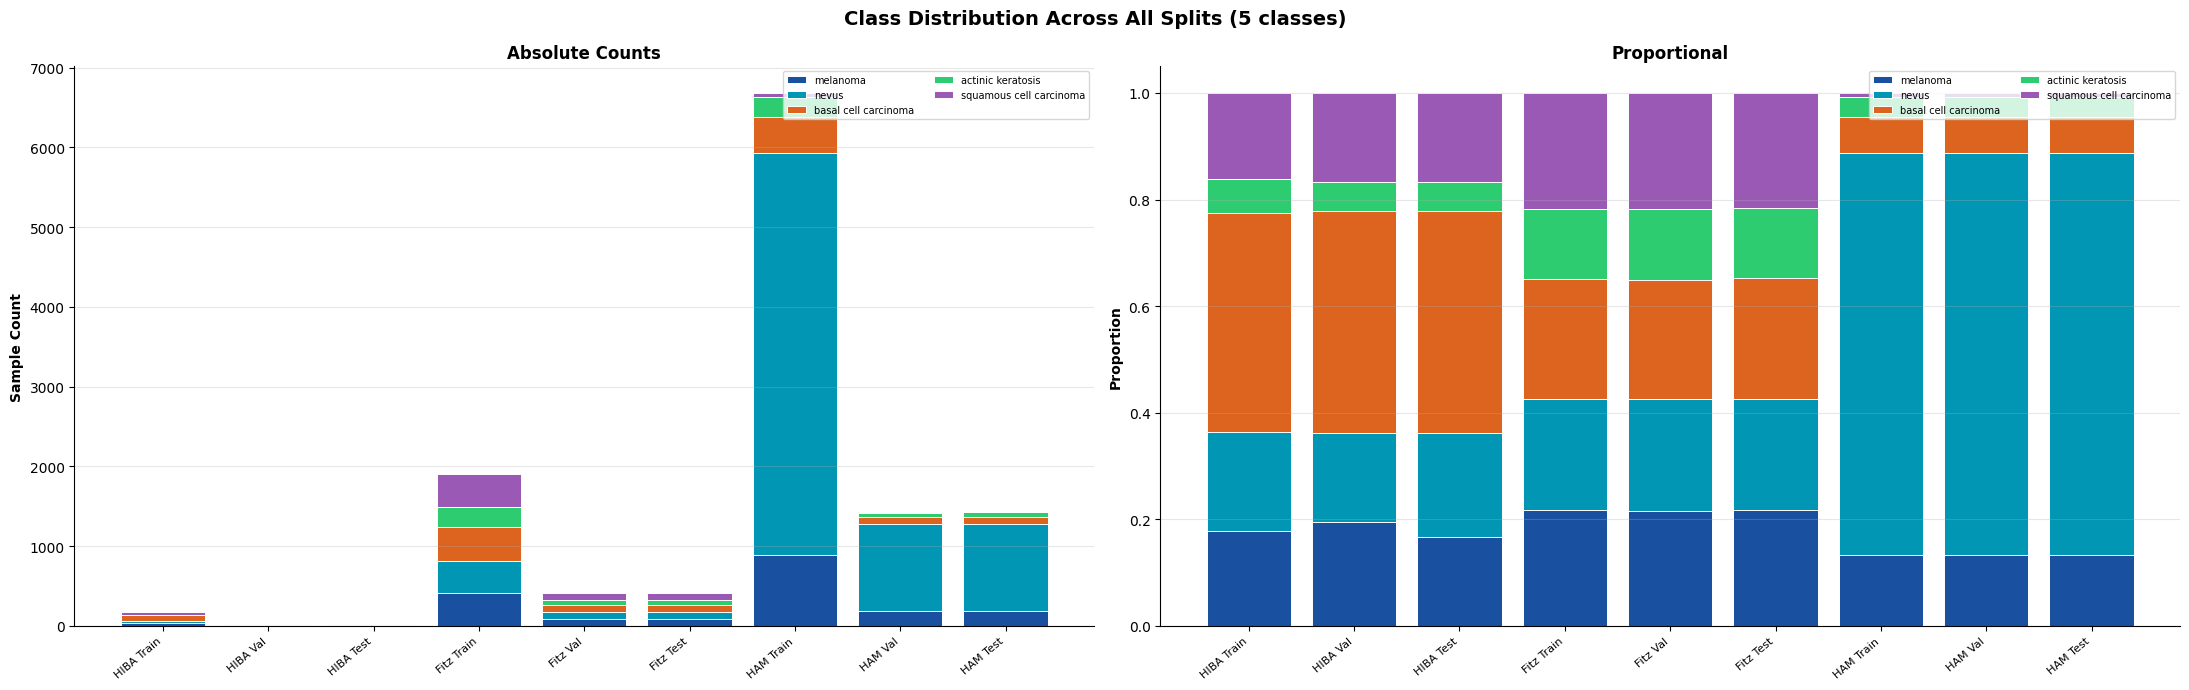

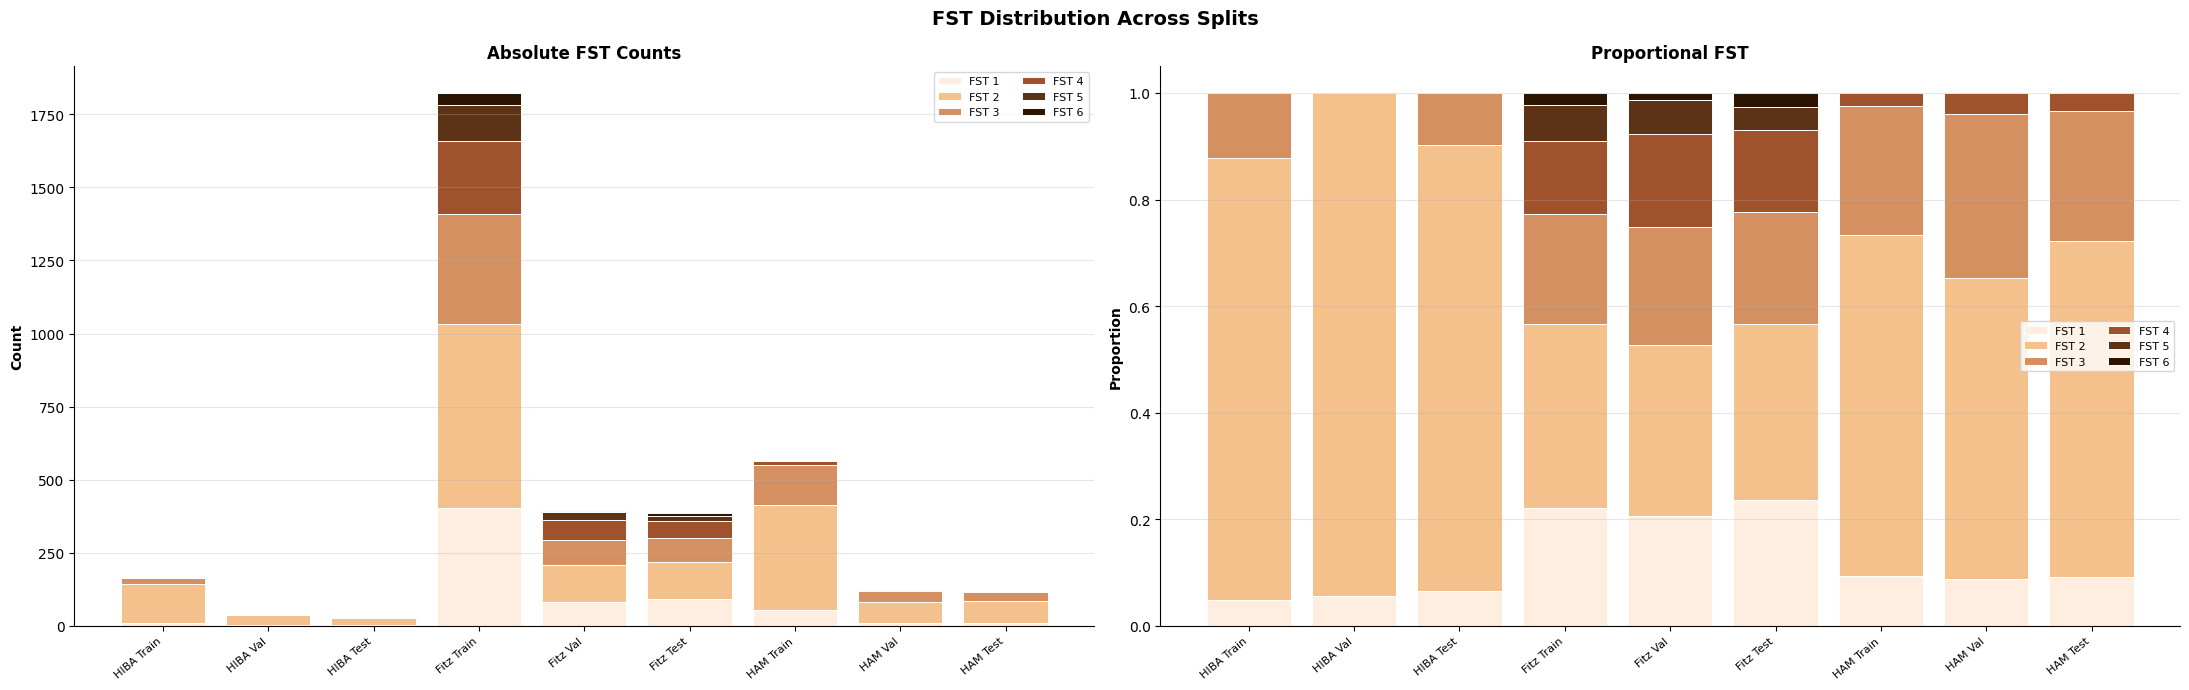

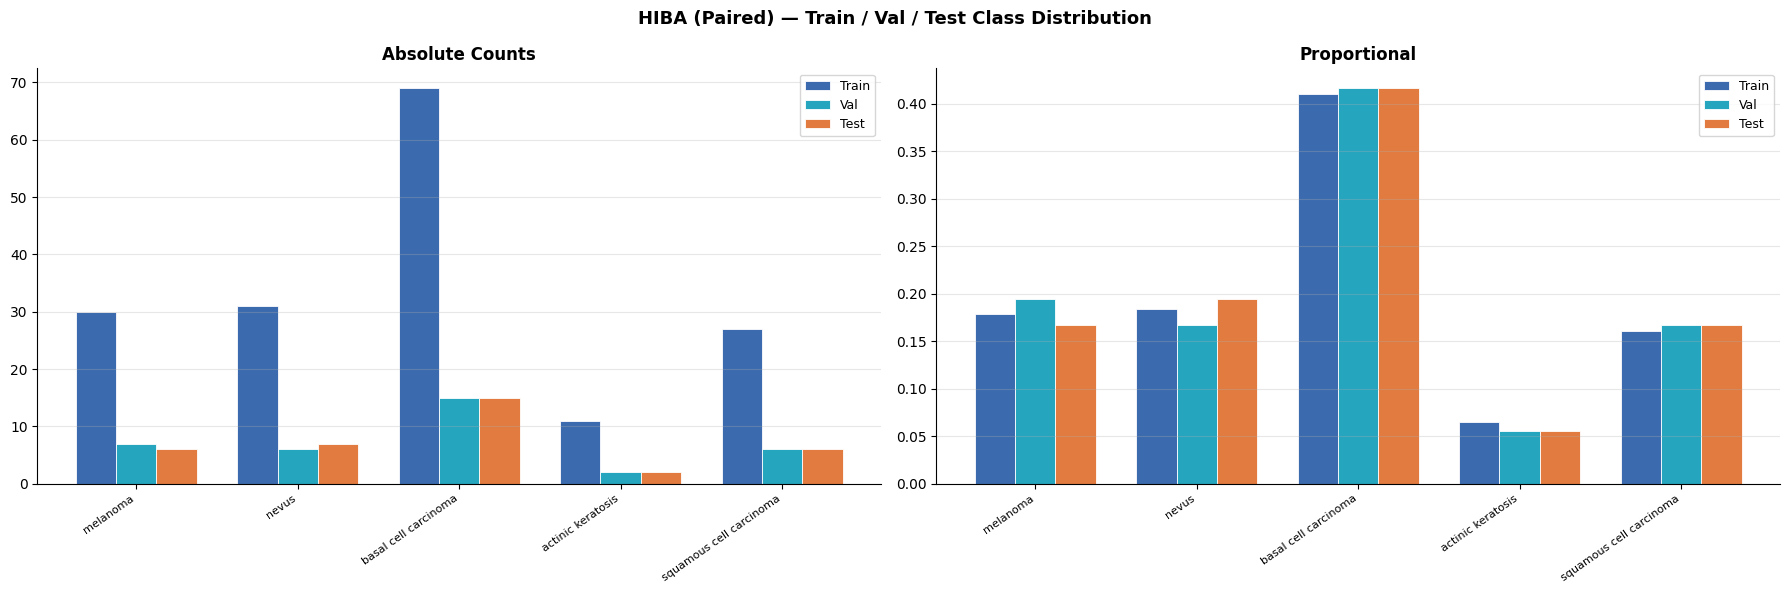

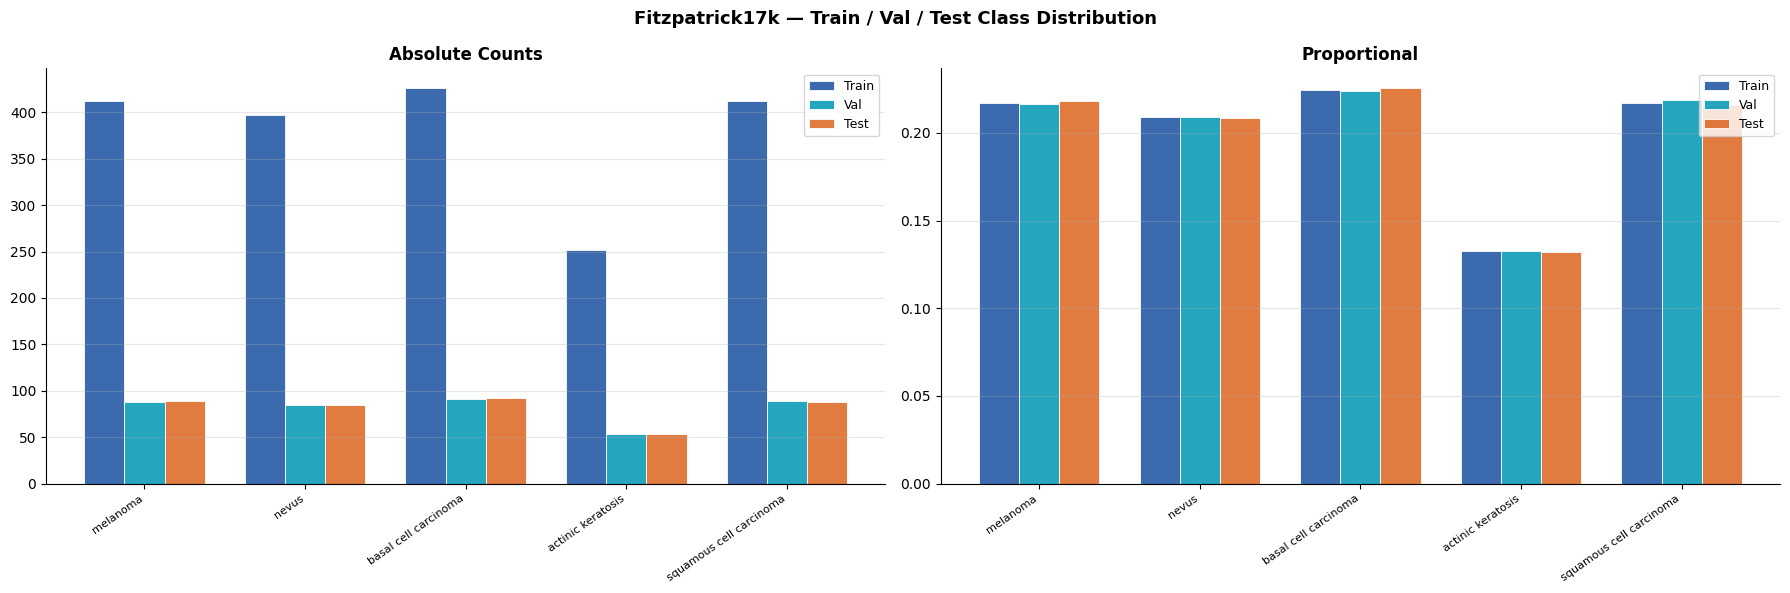

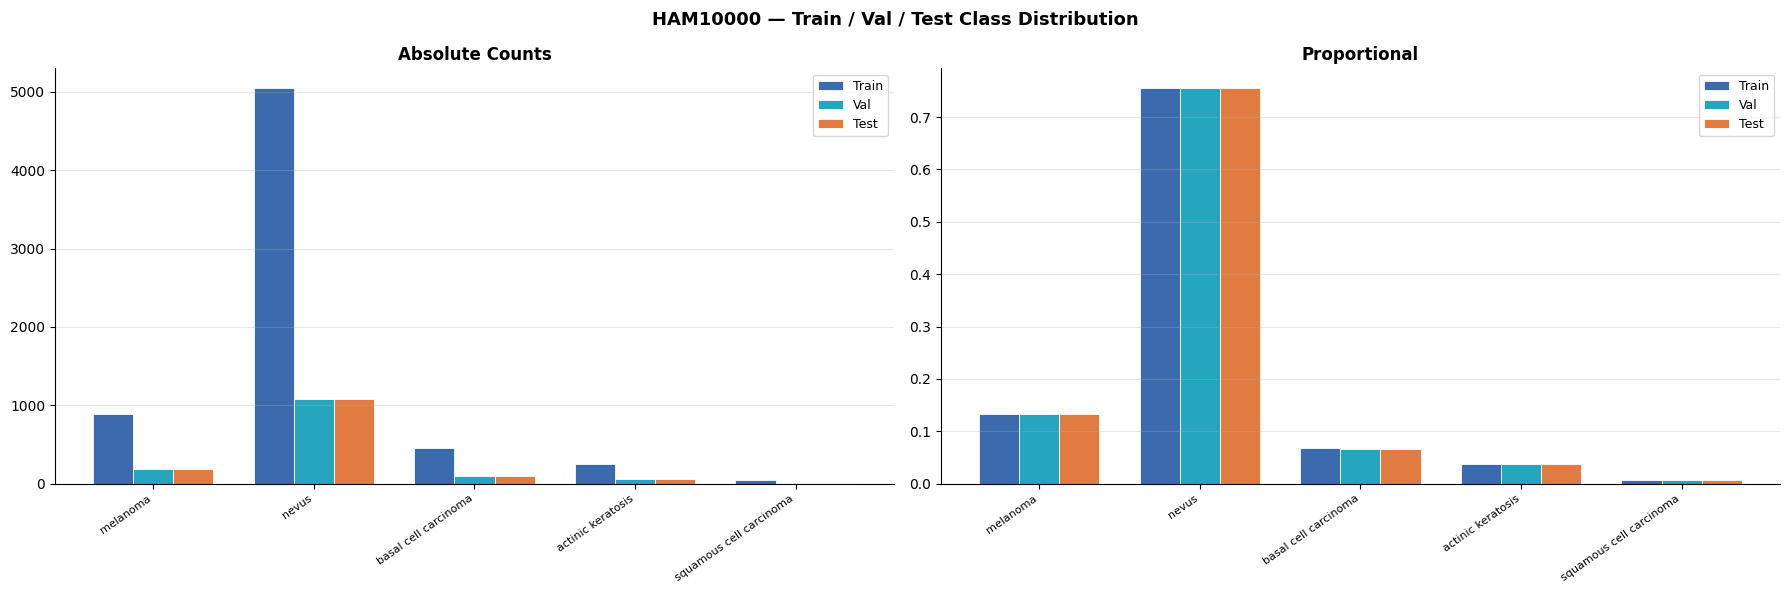

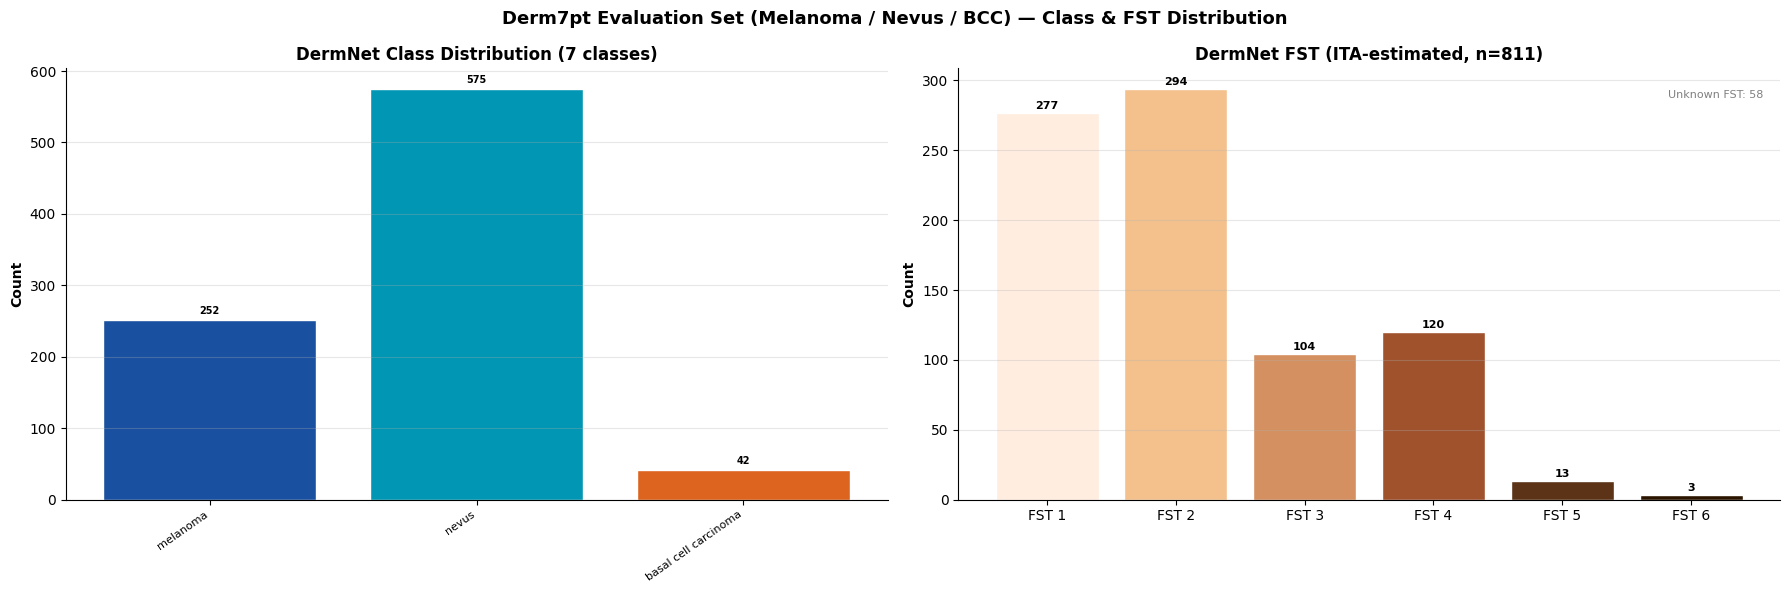

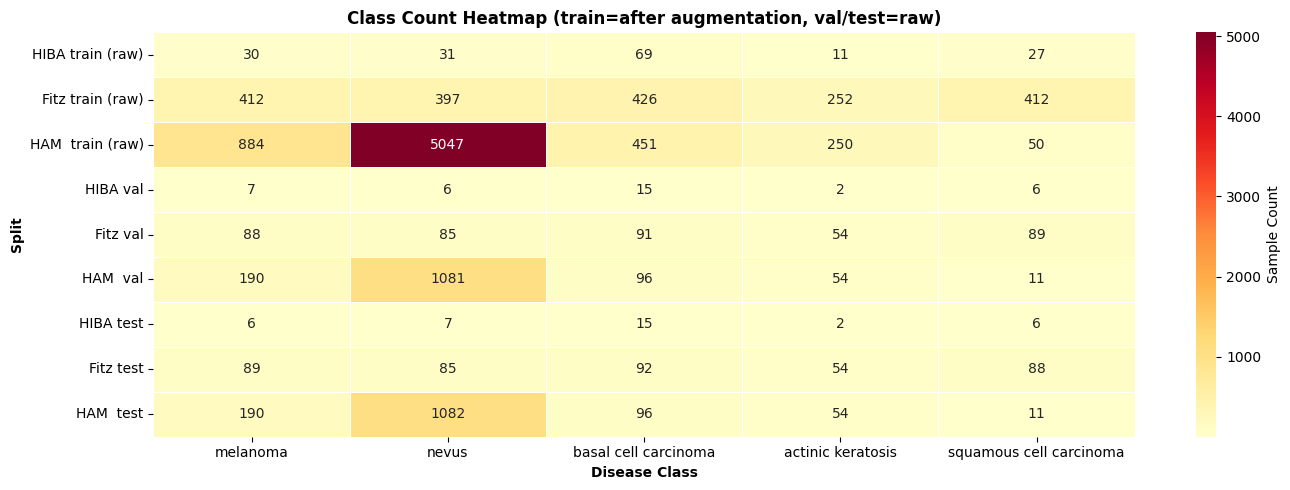


── Coverage Summary ─────────────────────────────────────
                Total rows  FST known  FST %
Dataset                                     
HIBA                   168        164  97.6%
Fitzpatrick17k        1899       1823  96.0%
HAM10000              6682        563   8.4%
Derm7pt                869        811  93.3%

EDA visualizations saved.


In [112]:
# ════════════════════════════════════════════════════════════════════════════
# EDA — DATASET DISTRIBUTION VISUALIZATIONS  (7 classes)
# ════════════════════════════════════════════════════════════════════════════
import warnings as _w; _w.filterwarnings('ignore')

_LN  = LABEL_NAMES                          # {0:'melanoma', …, 6:'other'}
_LBL = [_LN[i] for i in range(5)]           # ordered list
_FST = {i: f'FST {i+1}' for i in range(6)}

_PAL_CLS = ['#1950A0','#0096B4','#DC641E','#2ECC71','#9B59B6']
_PAL_FST = ['#FFEDE0','#F4C18C','#D49060','#A0522D','#5C3317','#2B1500']

csv_dir = CFG['csv_dir']
def _load(fname):
    p = csv_dir / fname
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

# ── Load all splits ───────────────────────────────────────────────────────
_splits = {}
for tag, fname in [
    ('HIBA Train', 'paired_train.csv'), ('HIBA Val', 'paired_val.csv'),   ('HIBA Test', 'paired_test.csv'),
    ('Fitz Train', 'clin_train.csv'),   ('Fitz Val', 'clin_val.csv'),     ('Fitz Test', 'clin_test.csv'),
    ('HAM Train',  'derm_train.csv'),   ('HAM Val',  'derm_val.csv'),     ('HAM Test',  'derm_test.csv'),
]:
    d = _load(fname)
    if d.empty: continue
    # normalise clinical_path → image_path for paired sets
    if 'image_id' not in d.columns and 'clinical_id' in d.columns:
        d = d.rename(columns={'clinical_id': 'image_id'})  # normalise for EDA
    _splits[tag] = d

_dermnet = _load('eval_derm7pt.csv')

# ──────────────────────────────────────────────────────────────────────────
# FIG 1  Class distribution across ALL splits (stacked absolute + proportional)
# ──────────────────────────────────────────────────────────────────────────
if _splits:
    _snames = list(_splits.keys())
    fig, axes = plt.subplots(1, 2, figsize=(22, 7))
    fig.suptitle('Class Distribution Across All Splits (5 classes)', fontsize=14, fontweight='bold')
    x = np.arange(len(_snames))
    bot_abs = np.zeros(len(_snames))
    bot_prop = np.zeros(len(_snames))
    totals = np.array([len(_splits[s]) for s in _snames], dtype=float)
    for ci in range(5):
        vals = np.array([_splits[s]['label'].value_counts().get(ci, 0) for s in _snames])
        axes[0].bar(x, vals, bottom=bot_abs,  color=_PAL_CLS[ci], label=_LBL[ci], edgecolor='white', lw=0.7)
        axes[1].bar(x, vals/np.maximum(totals,1), bottom=bot_prop, color=_PAL_CLS[ci], label=_LBL[ci], edgecolor='white', lw=0.7)
        bot_abs  += vals
        bot_prop += vals/np.maximum(totals,1)
    for ax, title, ylabel in [
        (axes[0], 'Absolute Counts', 'Sample Count'),
        (axes[1], 'Proportional',    'Proportion'),
    ]:
        ax.set_xticks(x); ax.set_xticklabels(_snames, rotation=40, ha='right', fontsize=8)
        ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylabel, fontweight='bold')
        ax.legend(fontsize=7, ncol=2, loc='upper right')
        ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(CFG['eda_dir']/'eda_class_all_splits.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 2  FST distribution (only splits with FST annotations)
# ──────────────────────────────────────────────────────────────────────────
_fst_splits = {s: d for s, d in _splits.items()
               if 'skin_type' in d.columns and (d['skin_type'] >= 0).any()}
if _fst_splits:
    _fs = list(_fst_splits.keys())
    fig, axes = plt.subplots(1, 2, figsize=(22, 7))
    fig.suptitle('FST Distribution Across Splits', fontsize=14, fontweight='bold')
    x = np.arange(len(_fs))
    bot_abs = np.zeros(len(_fs)); bot_prop = np.zeros(len(_fs))
    for fi in range(6):
        vals  = np.array([(d['skin_type'] == fi).sum() for d in _fst_splits.values()])
        known = np.array([(d['skin_type'] >= 0).sum() for d in _fst_splits.values()], dtype=float)
        axes[0].bar(x, vals, bottom=bot_abs,  color=_PAL_FST[fi], label=_FST[fi], edgecolor='white', lw=0.7)
        axes[1].bar(x, vals/np.maximum(known,1), bottom=bot_prop, color=_PAL_FST[fi], label=_FST[fi], edgecolor='white', lw=0.7)
        bot_abs  += vals
        bot_prop += vals/np.maximum(known,1)
    for ax, title, ylabel in [
        (axes[0], 'Absolute FST Counts', 'Count'),
        (axes[1], 'Proportional FST',    'Proportion'),
    ]:
        ax.set_xticks(x); ax.set_xticklabels(_fs, rotation=40, ha='right', fontsize=8)
        ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylabel, fontweight='bold')
        ax.legend(fontsize=8, ncol=2); ax.grid(axis='y', alpha=0.3)
        ax.spines[['top','right']].set_visible(False)
    axes[1].set_ylim(0, 1.05)
    plt.tight_layout()
    plt.savefig(CFG['eda_dir']/'eda_fst_all_splits.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 3  Per-dataset train/val/test grouped bar (class counts)
# ──────────────────────────────────────────────────────────────────────────
for ds_name, prefix, cols in [
    ('HIBA (Paired)',  'HIBA', ['HIBA Train','HIBA Val','HIBA Test']),
    ('Fitzpatrick17k', 'Fitz', ['Fitz Train','Fitz Val','Fitz Test']),
    ('HAM10000',       'HAM',  ['HAM Train', 'HAM Val', 'HAM Test']),
]:
    dfs = {c: _splits[c] for c in cols if c in _splits}
    if not dfs: continue
    present_cls = sorted(set(c for d in dfs.values() for c in d['label'].unique()))
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f'{ds_name} — Train / Val / Test Class Distribution', fontsize=13, fontweight='bold')
    split_labels = list(dfs.keys())
    x = np.arange(len(present_cls)); w = 0.25
    colors = ['#1950A0','#0096B4','#DC641E']
    for si, (sname, d) in enumerate(dfs.items()):
        cnts = [d['label'].value_counts().get(c, 0) for c in present_cls]
        axes[0].bar(x+(si-1)*w, cnts, w, label=sname.replace(prefix+' ',''),
                    color=colors[si], edgecolor='white', lw=0.7, alpha=0.85)
        props = np.array(cnts, dtype=float)/max(sum(cnts),1)
        axes[1].bar(x+(si-1)*w, props, w, label=sname.replace(prefix+' ',''),
                    color=colors[si], edgecolor='white', lw=0.7, alpha=0.85)
    for ax, title in [(axes[0],'Absolute Counts'),(axes[1],'Proportional')]:
        ax.set_xticks(x); ax.set_xticklabels([_LN.get(c,f'C{c}') for c in present_cls],
                                               rotation=35, ha='right', fontsize=8)
        ax.set_title(title, fontweight='bold'); ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(CFG['eda_dir']/f'eda_class_{prefix.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 4  DermNet class + FST (eval set)
# ──────────────────────────────────────────────────────────────────────────
if not _dermnet.empty:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle('Derm7pt Evaluation Set (Melanoma / Nevus / BCC) — Class & FST Distribution', fontsize=13, fontweight='bold')
    vc = _dermnet['label'].value_counts().sort_index()
    bar_cols = [_PAL_CLS[i % 7] for i in vc.index]
    bars = axes[0].bar([_LN.get(i,f'C{i}') for i in vc.index], vc.values,
                       color=bar_cols, edgecolor='white', lw=1)
    for b, n in zip(bars, vc.values):
        axes[0].text(b.get_x()+b.get_width()/2, n+vc.values.max()*0.01, str(n),
                     ha='center', va='bottom', fontsize=7, fontweight='bold')
    axes[0].set_title('DermNet Class Distribution (7 classes)', fontweight='bold')
    axes[0].set_xticklabels([_LN.get(i,f'C{i}') for i in vc.index], rotation=35, ha='right', fontsize=8)
    axes[0].set_ylabel('Count', fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3); axes[0].spines[['top','right']].set_visible(False)
    if 'skin_type' in _dermnet.columns:
        fst_k = _dermnet[_dermnet['skin_type'] >= 0]
        if not fst_k.empty:
            fst_ns = [(_dermnet['skin_type']==fi).sum() for fi in range(6)]
            b2 = axes[1].bar([_FST[fi] for fi in range(6)], fst_ns, color=_PAL_FST, edgecolor='white', lw=1)
            for bar, n in zip(b2, fst_ns):
                if n: axes[1].text(bar.get_x()+bar.get_width()/2, n+max(fst_ns)*0.01,
                                   str(n), ha='center', fontsize=8, fontweight='bold')
            axes[1].set_title(f'DermNet FST (ITA-estimated, n={len(fst_k)})', fontweight='bold')
            axes[1].set_ylabel('Count', fontweight='bold')
            axes[1].text(0.98, 0.95, f'Unknown FST: {(_dermnet["skin_type"]<0).sum()}',
                         transform=axes[1].transAxes, ha='right', va='top', fontsize=8, color='grey')
            axes[1].grid(axis='y', alpha=0.3); axes[1].spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(CFG['eda_dir']/'eda_derm7pt.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 5  Class imbalance heatmap — raw counts per (dataset × class)
# ──────────────────────────────────────────────────────────────────────────
_heatmap_splits = {
    'HIBA train (raw)':  pd.read_csv(csv_dir/'paired_train.csv') if (csv_dir/'paired_train.csv').exists() else pd.DataFrame(),
    'Fitz train (raw)':  pd.read_csv(csv_dir/'clin_train.csv')   if (csv_dir/'clin_train.csv').exists()   else pd.DataFrame(),
    'HAM  train (raw)':  pd.read_csv(csv_dir/'derm_train.csv')   if (csv_dir/'derm_train.csv').exists()   else pd.DataFrame(),
    'HIBA val':          pd.read_csv(csv_dir/'paired_val.csv')    if (csv_dir/'paired_val.csv').exists()  else pd.DataFrame(),
    'Fitz val':          pd.read_csv(csv_dir/'clin_val.csv')      if (csv_dir/'clin_val.csv').exists()      else pd.DataFrame(),
    'HAM  val':          pd.read_csv(csv_dir/'derm_val.csv')      if (csv_dir/'derm_val.csv').exists()      else pd.DataFrame(),
    'HIBA test':         pd.read_csv(csv_dir/'paired_test.csv')    if (csv_dir/'paired_test.csv').exists()  else pd.DataFrame(),
    'Fitz test':         pd.read_csv(csv_dir/'clin_test.csv')      if (csv_dir/'clin_test.csv').exists()      else pd.DataFrame(),
    'HAM  test':         pd.read_csv(csv_dir/'derm_test.csv')      if (csv_dir/'derm_test.csv').exists()      else pd.DataFrame(),
}
_hmap_data = {}
for name, d in _heatmap_splits.items():
    if d.empty: continue
    _hmap_data[name] = [d['label'].value_counts().get(ci, 0) for ci in range(5)]
if _hmap_data:
    import seaborn as sns
    _hm_df = pd.DataFrame(_hmap_data, index=[_LN[i] for i in range(5)]).T
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.heatmap(_hm_df, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
                linecolor='white', ax=ax, cbar_kws={'label': 'Sample Count'})
    ax.set_title('Class Count Heatmap (train=after augmentation, val/test=raw)',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Disease Class', fontweight='bold')
    ax.set_ylabel('Split', fontweight='bold')
    plt.tight_layout()
    plt.savefig(CFG['eda_dir']/'eda_imbalance_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

# ──────────────────────────────────────────────────────────────────────────
# FIG 6  Coverage summary: % images found + % FST known per dataset
# ──────────────────────────────────────────────────────────────────────────
_cov_rows = []
for tag, fname in [('HIBA','paired_train.csv'),('Fitzpatrick17k','clin_train.csv'),
                    ('HAM10000','derm_train.csv'),('Derm7pt','eval_derm7pt.csv')]:
    d = _load(fname)
    if d.empty: continue
    _img_col = 'image_id' if 'image_id' in d.columns else 'clinical'
    n_total  = len(d)
    n_fst    = int((d['skin_type'] >= 0).sum()) if 'skin_type' in d.columns else 0
    n_cls6   = int((d['label'] == 6).sum()) if 'label' in d.columns else 0
    _cov_rows.append({'Dataset': tag, 'Total rows': n_total,
                       'FST known': n_fst, 'FST %': f'{100*n_fst/max(n_total,1):.1f}%'})
if _cov_rows:
    _cov_df = pd.DataFrame(_cov_rows).set_index('Dataset')
    print('\n── Coverage Summary ─────────────────────────────────────')
    print(_cov_df.to_string())
    _cov_df.to_csv(CFG['eda_dir']/'eda_coverage_summary.csv')

print('\nEDA visualizations saved.')
